# 04 — Model Training & Comparison

Purpose: THIS is the notebook you'll screenshot/present for evaluators.
It trains every candidate model via `src.ml.train`, compares them with
`src.ml.evaluate`, and plots feature importance/confusion matrices --
using the exact same functions `train.py` calls in production, so the
model this notebook says is "best" is guaranteed to be the one that
actually gets saved to S3.


In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.ml.train import (
    load_feature_table, prepare_train_test, train_all_candidates,
    FEATURE_COLUMNS, LABEL_COLUMN,
)
from src.ml.evaluate import (
    compare_models, confusion_matrix_df, full_report, feature_importance_df,
)

with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

ml_config = config["ml"]
labels = ml_config["risk_label"]["buckets"]

## 1. Load the feature table

In [4]:
df = load_feature_table(config["s3"]["bucket"], config["s3"]["paths"]["processed_features"])
print(df.shape)
df[FEATURE_COLUMNS + [LABEL_COLUMN]].describe()

INFO:equirisk.ml.train:Loaded feature table: 168727 rows


(168727, 25)


,daily_return,volatility_20d,volatility_60d,volatility_90d,ma_20d,ma_60d,ma_90d,rsi_14,macd_line,macd_signal,daily_sentiment,sentiment_3d_avg,article_count
count,168577.000000,168427.000000,168427.000000,168427.000000,168727.000000,168727.000000,168727.000000,168727.000000,168727.000000,168727.000000,168727.000000,168727.000000,168727.000000
mean,0.000914,0.020911,0.021573,0.021762,3144.245209,3116.388774,3097.315213,52.231443,10.190321,10.127416,0.000006,0.000006,0.000041
std,0.022723,0.009153,0.007829,0.007514,11140.255730,11064.424937,11009.592456,17.399476,285.991141,273.019007,0.001751,0.001011,0.006441
min,-0.746132,0.000039,0.000039,0.000039,5.633242,5.840110,5.840110,0.000000,-7608.489834,-7231.955584,0.000000,0.000000,0.000000
25%,-0.010876,0.014761,0.016340,0.016734,310.150024,305.509446,301.194075,39.911316,-10.287573,-9.583138,0.000000,0.000000,0.000000
50%,0.000000,0.019144,0.020119,0.020390,816.717502,804.993660,798.371637,52.334598,0.750626,0.759123,0.000000,0.000000,0.000000
75%,0.011442,0.024887,0.025255,0.025332,2061.890350,2041.822294,2021.958830,64.799001,18.119702,17.207026,0.000000,0.000000,0.000000
max,0.286914,0.174251,0.161415,0.161415,158406.732031,154901.347396,153042.754167,100.000000,8689.399840,8485.541533,0.659700,0.219900,1.000000


## 2. Train/test split

In [ ]:
X_train, X_test, y_train, y_test, scaler, encoder = prepare_train_test(
    df,
    ml_config["train_test_split"],
    ml_config["random_state"],
    ml_config.get("train_test_gap_days", 30),
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Label distribution (train, decoded):")
pd.Series(encoder.inverse_transform(y_train)).value_counts()

## 3. Train all candidate models

In [15]:
trained = train_all_candidates(X_train, y_train, X_test, ml_config["candidate_models"], encoder)
list(trained.keys())

INFO:equirisk.ml.train:Training logistic_regression...
/home/moksha/EquiRisk/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
INFO:equirisk.ml.train:Training random_forest...
INFO:equirisk.ml.train:Training xgboost...
INFO:equirisk.ml.train:Training lightgbm...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 134501, number of used features: 10
[LightGBM] [Info] Start training from score -1.073691
[LightGBM] [Info] Start training from score -1.126744
[LightGBM] [Info] Start training from score -1.096110
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


['logistic_regression', 'random_forest', 'xgboost', 'lightgbm']

## 4. Compare models

In [16]:
y_test_labels = encoder.inverse_transform(y_test)
comparison_input = {name: (y_test_labels, y_pred) for name, (model, y_pred) in trained.items()}
comparison_table = compare_models(comparison_input, labels)
comparison_table

,accuracy,f1_macro,precision_macro,recall_macro
model,,,,
xgboost,0.765063,0.764951,0.764823,0.765101
lightgbm,0.669779,0.668341,0.667655,0.669692
random_forest,0.592369,0.588613,0.587789,0.591785
logistic_regression,0.527062,0.516757,0.514964,0.527748


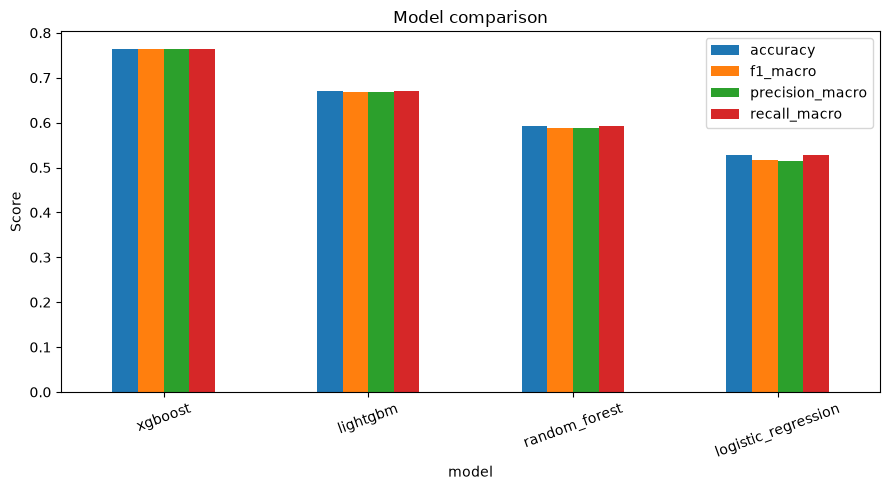

In [17]:
comparison_table[["accuracy", "f1_macro", "precision_macro", "recall_macro"]].plot(
    kind="bar", figsize=(9, 5), title="Model comparison"
)
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Confusion matrix + full report for the best model

In [ ]:
best_model_name = comparison_table.index[0]
best_model, best_y_pred = trained[best_model_name]
print("Best model:", best_model_name)

cm_df = confusion_matrix_df(y_test_labels, best_y_pred, labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix -- {best_model_name}")
plt.show()

print(full_report(y_test_labels, best_y_pred, labels))

## 6. Feature importance (tree-based models only)

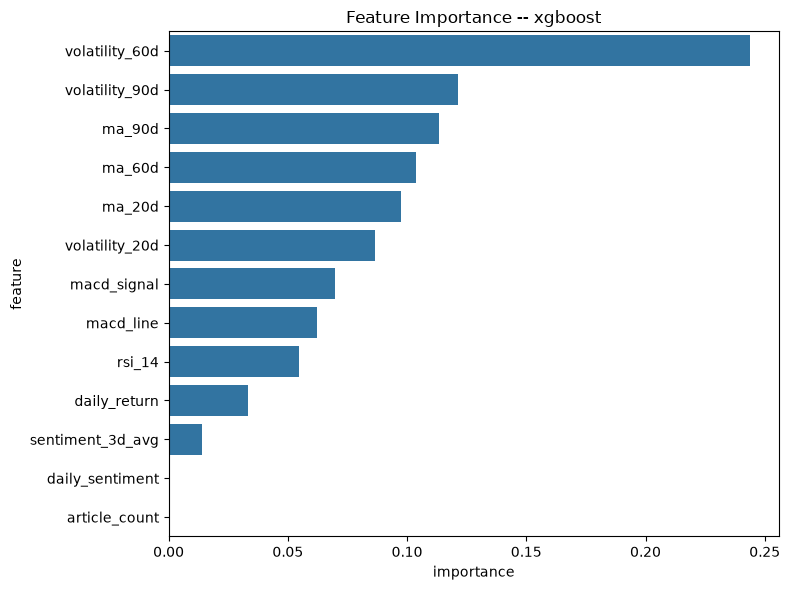

In [19]:
if hasattr(best_model, "feature_importances_"):
    fi_df = feature_importance_df(best_model, FEATURE_COLUMNS)
    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi_df, x="importance", y="feature")
    plt.title(f"Feature Importance -- {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no feature_importances_ -- skip (expected for Logistic Regression)")

## 7. Save the winning model to S3

This mirrors exactly what `src.ml.train.run_training()` does in
production -- run this cell only if you want THIS notebook run to be
the one that produces the saved model, otherwise just call
`run_training()` from the CLI/orchestrator instead.

In [20]:
# import io, joblib
# from src.utils.s3_io import put_bytes, model_key
#
# model_buf = io.BytesIO()
# joblib.dump(
#     {"model": best_model, "scaler": scaler, "encoder": encoder,
#      "features": FEATURE_COLUMNS, "labels": labels},
#     model_buf,
# )
# put_bytes(model_key(ml_config["model_version"], "model.pkl"), model_buf.getvalue(), config["s3"]["bucket"])
# print("Saved", best_model_name)